
This is just a preliminary model that I created and will work upon. For now I was able to find a Dataset online which had pH, Hardness, Solids, Chloramines, Sulphate, Conductivity, Organic_Carbon, Trihalomethane, Turbidity and Potability as attributes in .csv format which I loaded in this Google Colab Notebook and worked upon.




Similar resource link:
https://www.hackster.io/kutluhan-aktar/gsm-sms-enabled-ai-driven-tinyml-water-pollution-monitor-4a06e6

Kaggle Dataset Link:
https://www.kaggle.com/code/imakash3011/water-quality-prediction-7-model

# **Water Quality Prediction Using TinyML**  
This model is designed to predict whether water is potable (safe to drink) based on key chemical attributes such as pH, turbidity, conductivity, dissolved solids, and chloramines. The goal is to make real-time predictions using a lightweight neural network suitable for TinyML deployment on microcontrollers like ESP32.  


## Model Overview  
Preprocessing: Cleans missing values, scales features, and applies SMOTE to balance potable vs. non-potable samples.

Architecture: A small feedforward neural network (32-16-8-1 layers) for edge devices.

Training: Uses Adam optimizer with binary cross-entropy loss, tracking recall to improve potable water identification.

Evaluation: Analyzes accuracy, precision, recall, F1-score, and ROC AUC to measure model effectiveness.

Deployment: Converts the trained model to TensorFlow Lite (.tflite) for integration with IoT-based water monitoring systems.  




In this section, we load the dataset, clean missing values, normalize features, and split it into training and testing sets.


 Dataset Snapshot:
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  

 Data Shape (rows, columns): (3276, 10)

 Column Names: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_ca

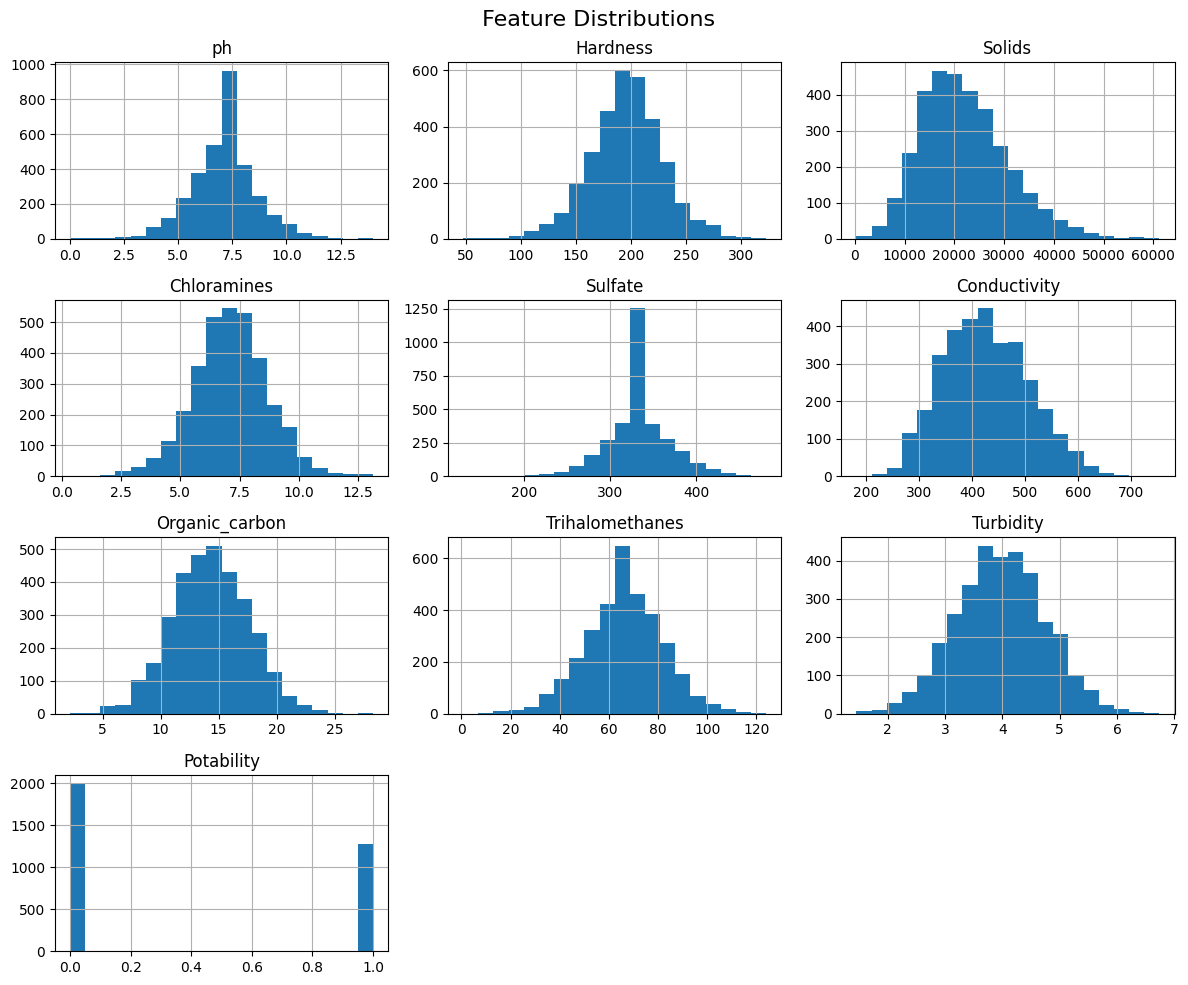

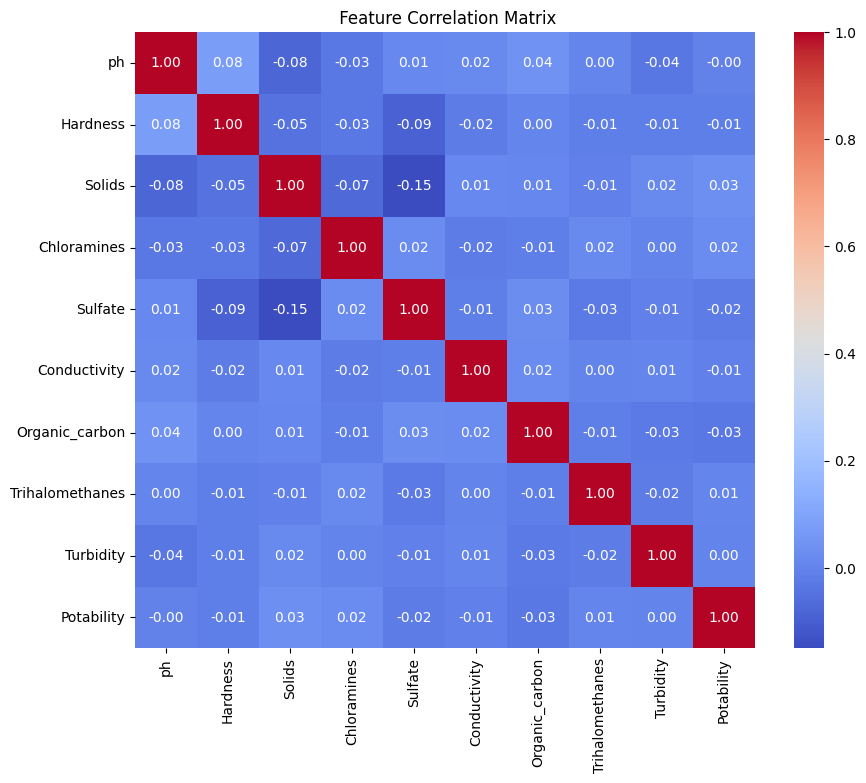


 Dataset Successfully Preprocessed!
 Dataset Balanced with SMOTE!

 Balanced Training Class Distribution:
Potability
0    1586
1    1586
Name: count, dtype: int64


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv("/content/water_potability.csv")

# Preview structure and metadata
print("\n Dataset Snapshot:")
print(df.head())

print("\n Data Shape (rows, columns):", df.shape)
print("\n Column Names:", df.columns.tolist())
print("\n Data Types:")
print(df.dtypes)

# Check missing values
print("\n Missing Values Per Column:")
print(df.isnull().sum())

# Basic statistics
print("\n Statistical Summary:")
print(df.describe())

# Handle missing values (replace with column mean)
df.fillna(df.mean(), inplace=True)

# Check class distribution
print("\n Potability Class Distribution:")
print(df["Potability"].value_counts())

# Visualize distributions
df.hist(figsize=(12, 10), bins=20)
plt.suptitle(" Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title(" Feature Correlation Matrix")
plt.show()

# Separate features and target
X = df.drop(columns=["Potability"])
y = df["Potability"]

# Normalize dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("\n Dataset Successfully Preprocessed!")

# Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(" Dataset Balanced with SMOTE!")

# Final class balance check after SMOTE
print("\n Balanced Training Class Distribution:")
print(pd.Series(y_train_bal).value_counts())


TinyML models need minimal computation. Here, we define a small feedforward neural network for water quality classification.

In [2]:
# # Import TensorFlow
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout

# # Define a TinyML-friendly neural network
# model = Sequential([
#     Dense(32, activation='relu', input_shape=(X_train_bal.shape[1],)),
#     Dropout(0.2),  # Prevent overfitting
#     Dense(16, activation='relu'),
#     Dense(8, activation='relu'),
#     Dense(1, activation='sigmoid')  # Binary classification
# ])

# # Compile model with accuracy tracking
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Train model and store history for evaluation
# history = model.fit(X_train_bal, y_train_bal, epochs=50, batch_size=16, validation_data=(X_test, y_test))
# print("Model Training Completed!")
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

# Define the model
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_bal.shape[1],),
          kernel_regularizer=regularizers.l2(0.001)),
    Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(4, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(1, activation='sigmoid')  # Binary output
])

# Compile with optimized metrics
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', AUC()]
)

# Set up early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_bal,
    y_train_bal,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

print("Model training completed!")

# Convert to TensorFlow Lite with quantization for deployment
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Enables quantization
tflite_model = converter.convert()

print("Model successfully converted to TensorFlow Lite!")



Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5083 - auc: 0.5014 - loss: 0.7412 - val_accuracy: 0.5305 - val_auc: 0.5830 - val_loss: 0.7204
Epoch 2/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5436 - auc: 0.5689 - loss: 0.7091 - val_accuracy: 0.5915 - val_auc: 0.6313 - val_loss: 0.6918
Epoch 3/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5886 - auc: 0.6245 - loss: 0.6928 - val_accuracy: 0.6280 - val_auc: 0.6476 - val_loss: 0.6791
Epoch 4/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6184 - auc: 0.6630 - loss: 0.6758 - val_accuracy: 0.6265 - val_auc: 0.6666 - val_loss: 0.6721
Epoch 5/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6174 - auc: 0.6939 - loss: 0.6560 - val_accuracy: 0.6402 - val_auc: 0.6765 - val_loss: 0.6538
Epoch 6/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6162 - auc: 0.6904 - loss: 0.6527 - val_accuracy: 0.6250 - val_auc: 0.6794 - val_loss: 0.6550
Epoch 7/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Here, we calculate accuracy, precision, recall, F1-score, ROC AUC, and confusion matrix to measure model performance.

In [3]:
# Import evaluation libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Predict on test set (Convert probabilities to binary values)
y_pred = (model.predict(X_test) > 0.5).astype("int")

# Compute Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy: 0.6448
Precision: 0.5219
Recall: 0.5369
F1-score: 0.5293
ROC AUC: 0.6228

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.71      0.71       412
           1       0.52      0.54      0.53       244

    accuracy                           0.64       656
   macro avg       0.62      0.62      0.62       656
weighted avg       0.65      0.64      0.65       656



The confusion matrix helps understand true positives, false positives, true negatives, and false negatives.

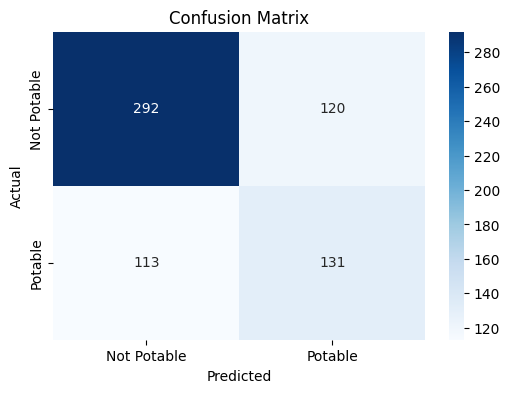

In [4]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Potable", "Potable"], yticklabels=["Not Potable", "Potable"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Accuracy & Loss Curve
These curves visualize training progress and help detect overfitting or underperformance.

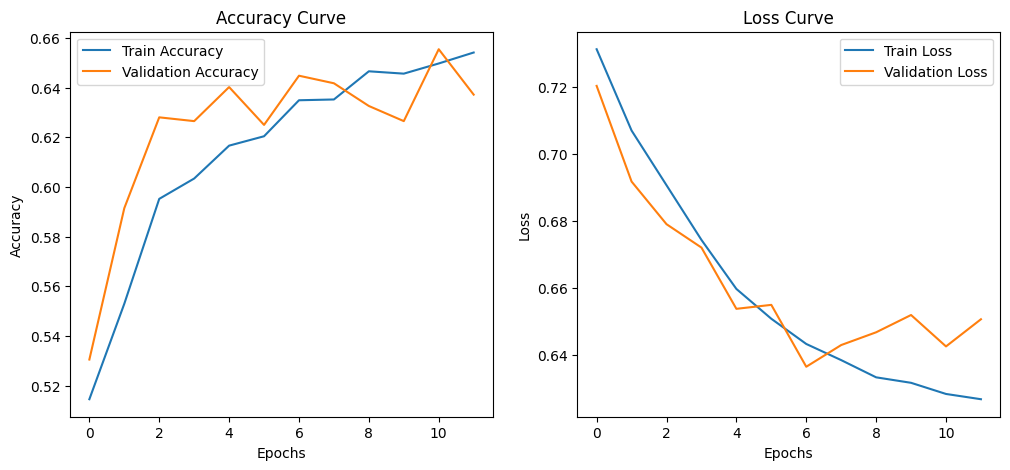

In [5]:
# Plot Accuracy & Loss Curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.show()


The ROC Curve helps evaluate the model’s ability to distinguish between potable and non-potable water.

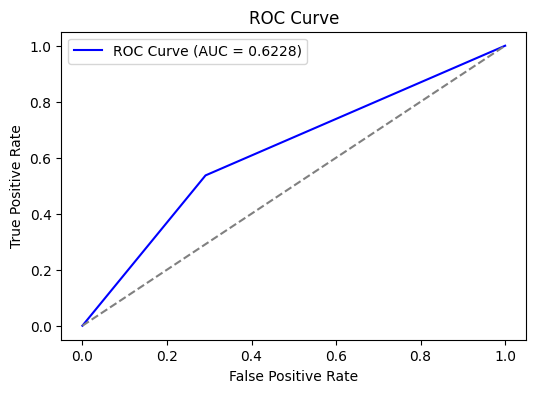

In [6]:
from sklearn.metrics import roc_curve

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)

# Plot ROC Curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label="ROC Curve (AUC = {:.4f})".format(roc_auc))
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Precision-Recall Curve
This curve helps visualize trade-offs between precision and recall, especially for imbalanced datasets.

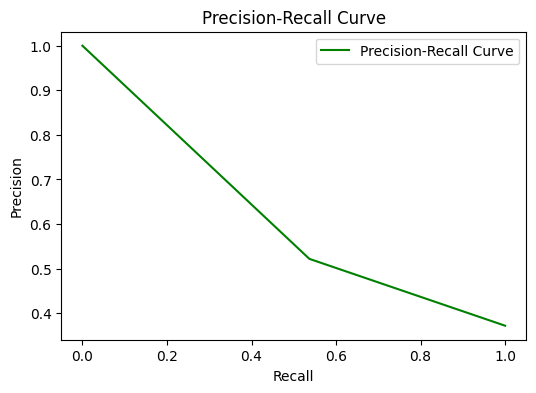

In [7]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred)

# Plot Precision-Recall Curve
plt.figure(figsize=(6,4))
plt.plot(recall_vals, precision_vals, color='green', label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


Convert Model for TinyML (TensorFlow Lite)
Since TinyML requires lightweight models, we convert the trained model to TensorFlow Lite (.tflite) for deployment on ESP32, Raspberry Pi, or microcontrollers.

In [8]:
# Convert the model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted model
with open("water_quality_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TinyML Model Saved as 'water_quality_model.tflite'!")


Saved artifact at '/tmp/tmputec8u0r'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 9), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134507513239632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134507513242896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134507513244624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134507513240400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134507513244816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134507513242512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134507513246544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134507513245392: TensorSpec(shape=(), dtype=tf.resource, name=None)
TinyML Model Saved as 'water_quality_model.tflite'!


In [9]:
import os

# Get size in bytes and convert to megabytes
size_bytes = os.path.getsize("water_quality_model.tflite")
size_mb = size_bytes / (1024)
print(f"Model size: {size_mb:.2f} KB")


Model size: 3.70 KB
